## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

In [61]:
print(" LOADING DATASET...")

df = pd.read_excel('/content/Credit-Card-Default-Dataset(Taiwan).xls')
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
df.head(10)

 LOADING DATASET...

Dataset Shape: (30001, 25)
Total Records: 30,001
Total Features: 25


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
9,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0


## Step 3: Data Exploration

In [62]:
print(" DATA EXPLORATION")
df.info()

 DATA EXPLORATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  

In [63]:
missing = df.isnull().sum()
print("Missing Values:")
print("No missing values!" if missing.sum() == 0 else missing[missing > 0])

Missing Values:
No missing values!


In [64]:
df.describe()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,...,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001
unique,30001,82,3,8,5,57,12,12,12,12,...,21549,21011,20605,7944,7900,7519,6938,6898,6940,3
top,30000,50000,2,2,2,29,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,1,3365,18112,14030,15964,1605,14737,15730,15764,16455,...,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


In [9]:
# Check class distribution
print("\n\nTarget Variable Distribution:")
if 'default payment next month' in df.columns:
    target_col = 'default payment next month'
elif 'default.payment.next.month' in df.columns:
    target_col = 'default.payment.next.month'
else:
    # Find the last column (usually the target)
    target_col = df.columns[-1]

print(df[target_col].value_counts())
print(f"\nClass Distribution (%):")
print(df[target_col].value_counts(normalize=True) * 100)




Target Variable Distribution:
Y
0                             23364
1                              6636
default payment next month        1
Name: count, dtype: int64

Class Distribution (%):
Y
0                             77.877404
1                             22.119263
default payment next month     0.003333
Name: proportion, dtype: float64


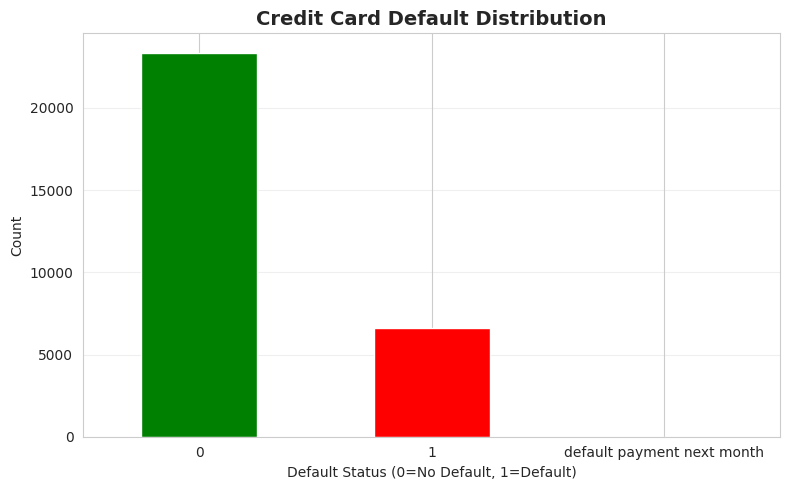

In [10]:
plt.figure(figsize=(8, 5))
df[target_col].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Credit Card Default Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Default Status (0=No Default, 1=Default)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [11]:
print("DATA PREPROCESSING")

X = df.drop([target_col, 'ID'], axis=1, errors='ignore')
y = df[target_col]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

DATA PREPROCESSING
Features: (30001, 24)
Target: (30001,)


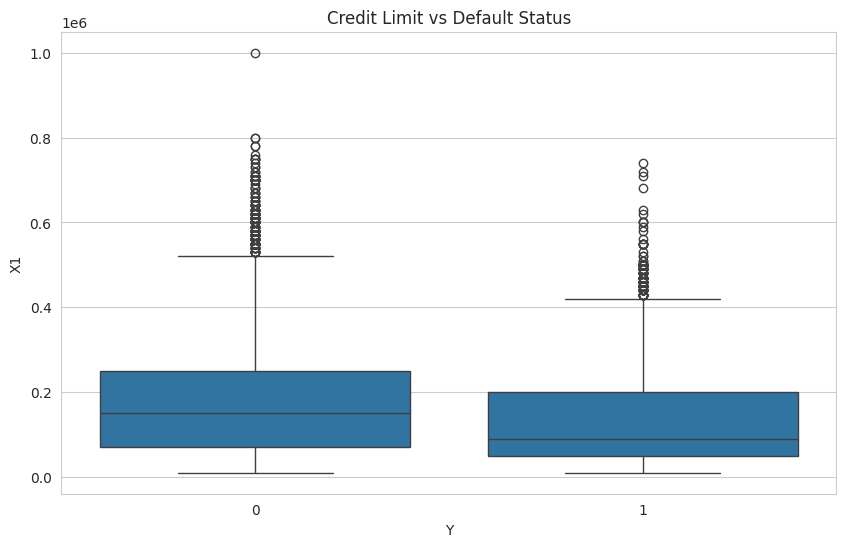

In [77]:
# Create a cleaned DataFrame for plotting
df_plot = df.iloc[1:].copy()
df_plot['X1'] = pd.to_numeric(df_plot['X1']) # Ensure X1 is numeric
df_plot[target_col] = pd.to_numeric(df_plot[target_col]).astype(int) # Ensure target_col is numeric/int

sns.boxplot(x=target_col, y='X1', data=df_plot)
plt.title("Credit Limit vs Default Status")
plt.show()

In [32]:
print("Scaling features...")
X_temp = X.copy()
y_temp = y.copy()

X_temp = X_temp.iloc[1:]
y_temp = y_temp.iloc[1:]
X_temp = X_temp.apply(pd.to_numeric, errors='coerce')

# Convert y_temp to numeric type (int) for classification models
y_temp = pd.to_numeric(y_temp, errors='coerce').astype(int)

# Now, X_temp contains only numeric data, and y_temp is aligned and numeric.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_temp) # Use X_temp for scaling
X_scaled = pd.DataFrame(X_scaled, columns=X_temp.columns) # Use X_temp.columns for new DataFrame

print(" Features scaled successfully!")

Scaling features...
 Features scaled successfully!


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Train: 24,000 | Test: 6,000


## Step 5: Model Training

In [34]:
results = {}

def evaluate_model(model, name, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)

    results[name] = {'Model': model, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc,
                     'Predictions': y_pred, 'Probabilities': y_prob}

    print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    print(f"\nConfusion Matrix: TN={cm[0][0]}, FP={cm[0][1]}, FN={cm[1][0]}, TP={cm[1][1]}")
    return model

## Step: 5.1 Logistic regression

In [53]:
lr = LogisticRegression(max_iter=1000, random_state=42)

In [54]:
lr = evaluate_model(lr, "Logistic Regression", X_train, X_test, y_train, y_test)

Accuracy:  0.8085 (80.85%)
Precision: 0.6918
Recall:    0.2419
F1-Score:  0.3585
ROC-AUC:   0.7078

Confusion Matrix: TN=4530, FP=143, FN=1006, TP=321


## Step: 5.2 RANDOM FOREST

In [55]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [56]:
rf = evaluate_model(rf, "Random Forest", X_train, X_test, y_train, y_test)

Accuracy:  0.8148 (81.48%)
Precision: 0.6429
Recall:    0.3662
F1-Score:  0.4666
ROC-AUC:   0.7568

Confusion Matrix: TN=4403, FP=270, FN=841, TP=486


## Step: 5.3 GRADIENT BOOSTING

In [57]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [58]:
gb = evaluate_model(gb, "Gradient Boosting", X_train, X_test, y_train, y_test)

Accuracy:  0.8193 (81.93%)
Precision: 0.6685
Recall:    0.3632
F1-Score:  0.4707
ROC-AUC:   0.7790

Confusion Matrix: TN=4434, FP=239, FN=845, TP=482


## Step 6: Model Comparison

In [40]:
comp = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'Precision': [results[m]['Precision'] for m in results],
    'Recall': [results[m]['Recall'] for m in results],
    'F1-Score': [results[m]['F1-Score'] for m in results],
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results]
})

best = comp.loc[comp['Accuracy'].idxmax(), 'Model']
print(f"\n BEST MODEL: {best}")
print(f"Accuracy: {comp['Accuracy'].max()*100:.2f}%\n")
comp


 BEST MODEL: Gradient Boosting
Accuracy: 81.93%



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.808500,0.691810,0.241899,0.358459,0.707757
1,Random Forest,0.814833,0.642857,0.366240,0.466635,0.756830
2,Gradient Boosting,0.819333,0.668516,0.363225,0.470703,0.779022


## Step 7: Visualizations

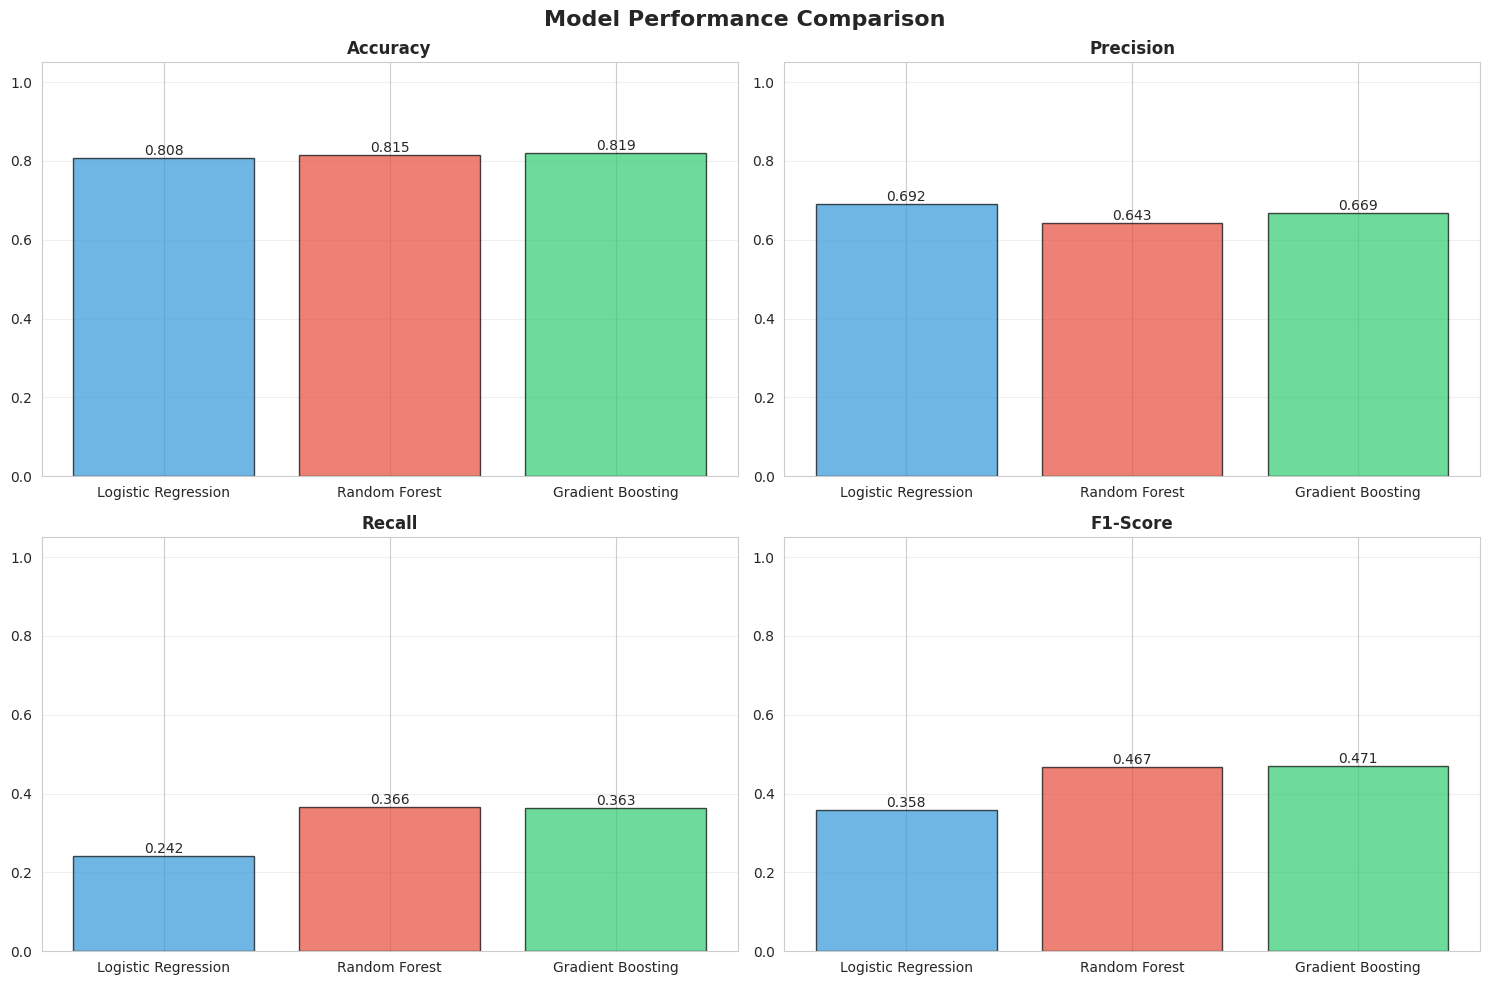

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, m in enumerate(metrics):
    ax = axes[i//2, i%2]
    bars = ax.bar(comp['Model'], comp[m], color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(m, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

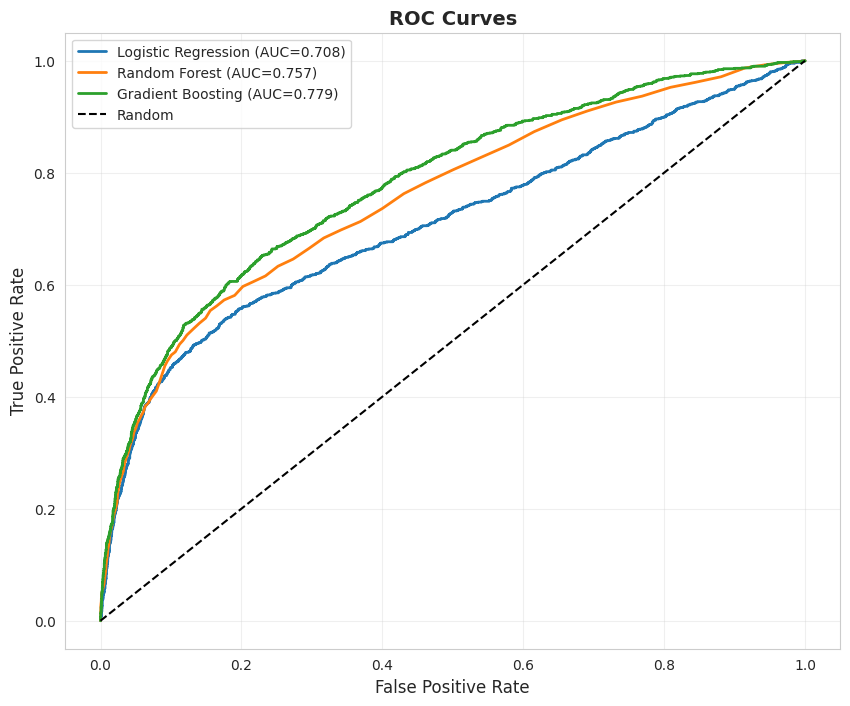

In [42]:
plt.figure(figsize=(10, 8))
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['Probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

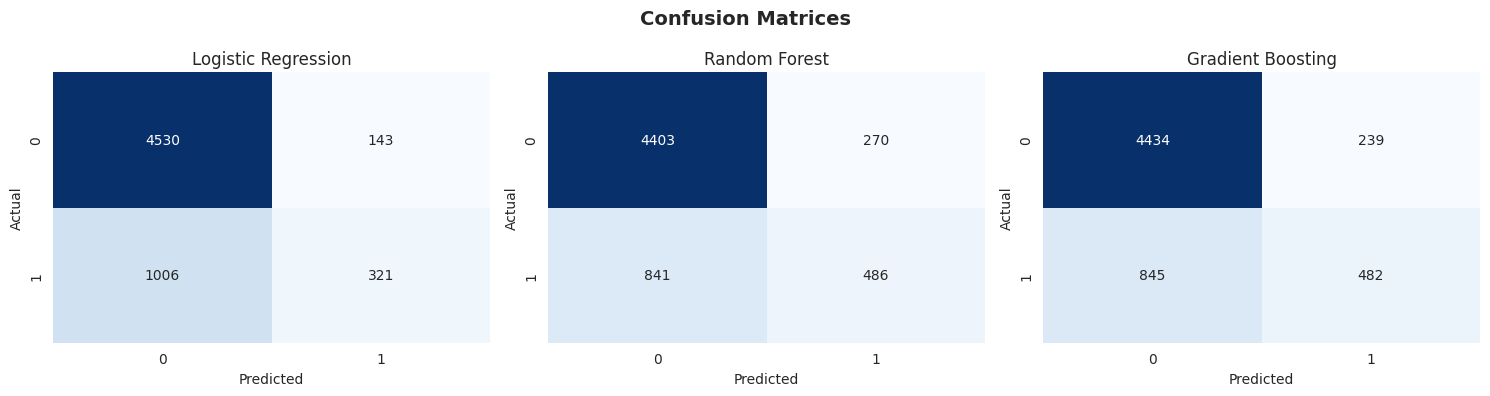

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for i, name in enumerate(results):
    cm = confusion_matrix(y_test, results[name]['Predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [68]:
print(f"DETAILED ANALYSIS OF BEST MODEL: {best}")

# The variable 'models' is not defined. The model objects are stored directly in the 'results' dictionary.
best_model = results[best]['Model']
best_results = results[best]

print(f"\n Performance Metrics:")
print(f"   Accuracy:  {best_results['Accuracy']:.4f} ({best_results['Accuracy']*100:.2f}%)")
print(f"   Precision: {best_results['Precision']:.4f}")
print(f"   Recall:    {best_results['Recall']:.4f}")
print(f"   F1-Score:  {best_results['F1-Score']:.4f}")
print(f"   ROC-AUC:   {best_results['ROC-AUC']:.4f}")

print(f"\n Confusion Matrix Analysis:")
# The 'Confusion Matrix' key is not stored in the 'results' dictionary.
# We need to compute it again or modify evaluate_model to store it.
# For now, let's recompute it using the stored predictions.
cm = confusion_matrix(y_test, best_results['Predictions'])
tn, fp, fn, tp = cm.ravel()
print(f"   True Negatives (TN):  {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")
print(f"   True Positives (TP):  {tp}")

DETAILED ANALYSIS OF BEST MODEL: Gradient Boosting

 Performance Metrics:
   Accuracy:  0.8193 (81.93%)
   Precision: 0.6685
   Recall:    0.3632
   F1-Score:  0.4707
   ROC-AUC:   0.7790

 Confusion Matrix Analysis:
   True Negatives (TN):  4434
   False Positives (FP): 239
   False Negatives (FN): 845
   True Positives (TP):  482


## Step 8: Feature Importance

In [70]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Features:")
feat_imp.head(15)

Top 15 Features:


,Feature,Importance
6,X6,0.093286
0,Unnamed: 0,0.071426
5,X5,0.056722
12,X12,0.055043
1,X1,0.051537
13,X13,0.049945
18,X18,0.047794
14,X14,0.047522
17,X17,0.046560
15,X15,0.045993


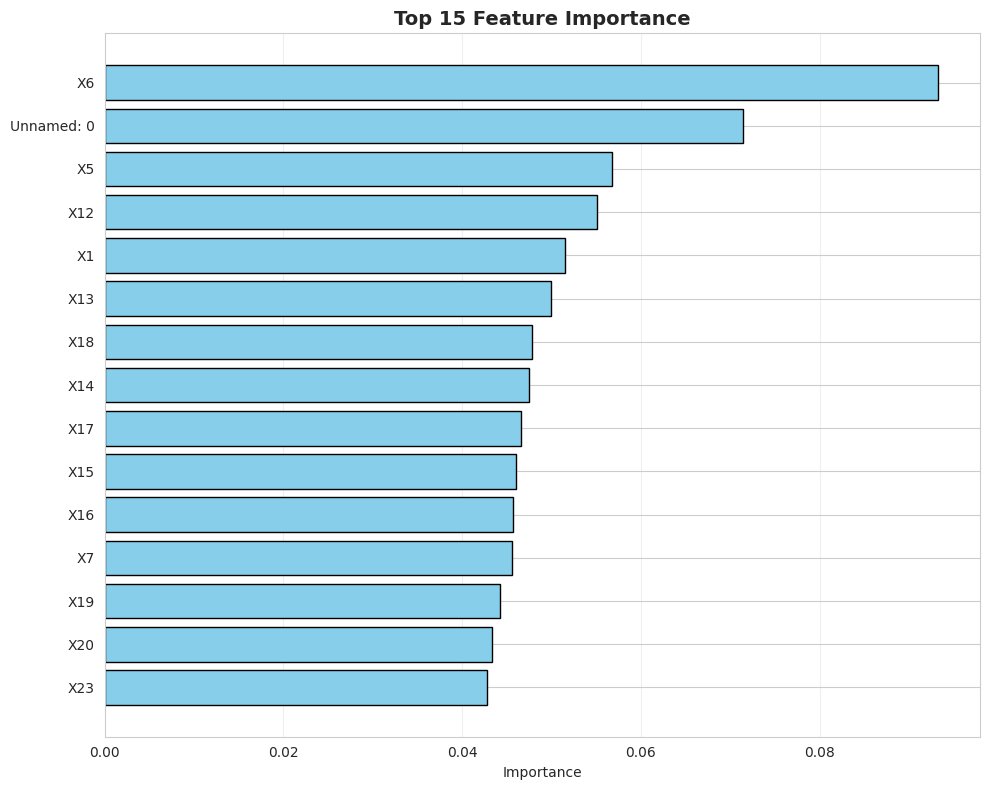

In [73]:
plt.figure(figsize=(10, 8))
top = feat_imp.head(15)
plt.barh(range(len(top)), top['Importance'], color='skyblue', edgecolor='black')
plt.yticks(range(len(top)), top['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Prediction Example

In [75]:
best_model = results[best]['Model']
sample = X_test.iloc[0:1]
actual = y_test.iloc[0]

pred = best_model.predict(sample)[0]
prob = best_model.predict_proba(sample)[0]

print(f"Actual: {'Default' if actual == 1 else 'No Default'}")
print(f"Predicted: {'Default' if pred == 1 else 'No Default'}")
print(f"Confidence: {max(prob)*100:.2f}%")
print(f"Result: {' Correct' if pred == actual else 'Wrong'}")

Actual: No Default
Predicted: No Default
Confidence: 86.85%
Result:  Correct


In [76]:
comp.to_csv('model_comparison.csv', index=False)
feat_imp.to_csv('feature_importance.csv', index=False)

print(f"\n PROJECT COMPLETED!")
print(f"Best Model: {best} ({comp['Accuracy'].max()*100:.2f}% accuracy)")


 PROJECT COMPLETED!
Best Model: Gradient Boosting (81.93% accuracy)
